---

## Nonlinear Filtering in Finance: Stochastic Volatility Tracking

One of the most classical problems in quantitative finance is estimating the unobservable volatility (variance of asset returns) that changes dynamically over time. In a widely used discrete-time model, the *log-volatility* $x_k$ follows an autoregressive process, and the observed measurement $z_k$ is an option-implied volatility proxy that depends nonlinearly on the hidden state.

**System Model:** Let $x_k$ be the hidden log-volatility at day $k$.

$$
x_k = \phi x_{k-1} + w_k, \qquad w_k \sim \mathcal{N}(0, Q) \tag{1}
$$

where $\phi = 0.95$ represents a high persistence (volatility clustering), and the process noise variance is $Q = 0.1$. The initial state is $x_0 \sim \mathcal{N}(0, 1)$.

**Measurement Model:** The sensor (e.g., an implied volatility index computed from derivatives) captures a noisy, exponentiated version of the state:

$$
z_k = \exp\!\left(\frac{x_k}{2}\right) + v_k, \qquad v_k \sim \mathcal{N}(0, R) \tag{2}
$$

where the measurement noise variance is $R = 0.05$.

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ──────────────────────────────────────────────
np.random.seed(42)
N   = 500      # number of time steps
phi = 0.95     # AR coefficient (volatility persistence)
Q   = 0.1      # process noise variance
R   = 0.05     # measurement noise variance

# ── Simulate True State x_k and Measurements z_k ───────────
x = np.zeros(N + 1)
z = np.zeros(N)

x[0] = np.random.normal(0, 1)          # x0 ~ N(0, 1)

for k in range(1, N + 1):
    w      = np.random.normal(0, np.sqrt(Q))
    x[k]   = phi * x[k-1] + w  # x_k = phi * x_{k-1} + w_k

for k in range(N):
    v      = np.random.normal(0, np.sqrt(R)) # v_k ~ N(0, R)
    z[k]   = np.exp(x[k+1] / 2) + v    # z_k = exp(x_k/2) + v_k


x_true = x[1:]                          # shape (N,)
time   = np.arange(1, N + 1)


import os
os.makedirs("output", exist_ok=True)
np.save("output/x_true.npy", x_true)
np.save("output/z_meas.npy", z)

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Part 1: Stochastic Volatility Simulation (N=500 Days)", fontsize=14, fontweight='bold')

# True log-volatility state
axes[0].plot(time, x_true, color='steelblue', linewidth=1.2, label=r'True state $x_k$ (log-volatility)')
axes[0].set_ylabel(r'$x_k$', fontsize=12)
axes[0].set_title('True Hidden Log-Volatility State')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.4)

#  Noisy measurements
axes[1].plot(time, z, color='darkorange', linewidth=0.8, alpha=0.85, label=r'Noisy measurement $z_k = \exp(x_k/2) + v_k$')
axes[1].set_ylabel(r'$z_k$', fontsize=12)
axes[1].set_xlabel('Time step $k$ (days)', fontsize=12)
axes[1].set_title('Observed Noisy Measurements (Implied Volatility Proxy)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("output/part1_simulation.png", dpi=150, bbox_inches='tight')
plt.close()
print("Saved: output/part1_simulation.png")
print(f"x_true range: [{x_true.min():.3f}, {x_true.max():.3f}]")
print(f"z range:      [{z.min():.3f}, {z.max():.3f}]")

Saved: output/part1_simulation.png
x_true range: [-1.932, 2.242]
z range:      [-0.131, 3.335]


---

## Part 2: Extended Kalman Filter (EKF)

We now apply the **Extended Kalman Filter** implemented in `Finance_EKF.py` to estimate the hidden log-volatility $x_k$ from the noisy measurements $z_k$ generated above.

The EKF linearises the nonlinear measurement function $h(x) = \exp(x/2)$ around the current prior estimate using its Jacobian:

$$
H_k = \frac{\partial h}{\partial x}\bigg|_{\hat{x}_{k|k-1}} = \frac{1}{2}\exp\!\left(\frac{\hat{x}_{k|k-1}}{2}\right)
$$

The filter then runs the standard Kalman predict–update cycle:

| Step | Equation |
|------|----------|
| **Predict** | $\hat{x}_{k \mid k-1} = \phi\,\hat{x}_{k-1 \mid k-1}$ |
|  | $P_{k \mid k-1} = \phi^2 P_{k-1 \mid k-1} + Q$ |
| **Update** | $K_k = P_{k \mid k-1} H_k \;/\; (H_k P_{k \mid k-1} H_k + R)$ |
|  | $\hat{x}_{k \mid k} = \hat{x}_{k \mid k-1} + K_k (z_k - h(\hat{x}_{k \mid k-1}))$ |
|  | $P_{k \mid k} = (1 - K_k H_k)\,P_{k \mid k-1}$ |

In [21]:
import numpy as np
import sys, os, logging, importlib
sys.path.insert(0, os.path.dirname(os.path.abspath('Finance_EKF.py')))

# Force reload so the kernel always picks up the latest Finance_EKF.py
import Finance_EKF
importlib.reload(Finance_EKF)
from Finance_EKF import StochasticVolatilityModel, ExtendedKalmanFilter, setup_logging

# Configure logging — use DEBUG to see every predict/update step,
# or INFO for a clean summary.
setup_logging(level=logging.INFO, log_file='output/ekf_run.log')

# Instantiate model and filter (same parameters as Part 1)
model = StochasticVolatilityModel(phi=phi, Q=Q, R=R)
ekf   = ExtendedKalmanFilter(model, x0=0.0, P0=1.0)

# Run EKF over the simulated measurement sequence
ekf.run(z)

# Extract results
results = ekf.get_results()
x_est   = results['x_est']
P_est   = results['P_est']
innov   = results['innov']

# Save to disk
os.makedirs('output', exist_ok=True)
for key, val in results.items():
    np.save(f'output/{key}.npy', val)


[20:08:27] INFO     | Finance_EKF | ExtendedKalmanFilter initialised | x0=0.0000  P0=1.0000
[20:08:27] INFO     | Finance_EKF | Starting EKF run over 500 measurements …
[20:08:27] INFO     | Finance_EKF | EKF run complete | N=500 | innovation mean=0.003889  std=0.332637 | final x_est=0.1424  final P_est=0.098269


[20:08:42] INFO     | Finance_EKF | Saved → output/plot1_state_estimate.png


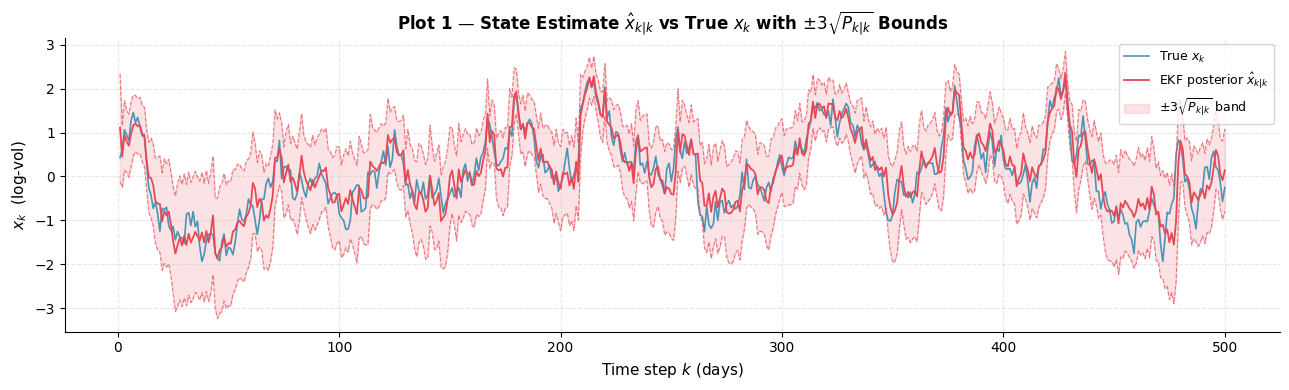

[20:08:42] INFO     | Finance_EKF | RMSE over full run: 0.321489
[20:08:44] INFO     | Finance_EKF | Saved → output/plot2_estimation_error.png


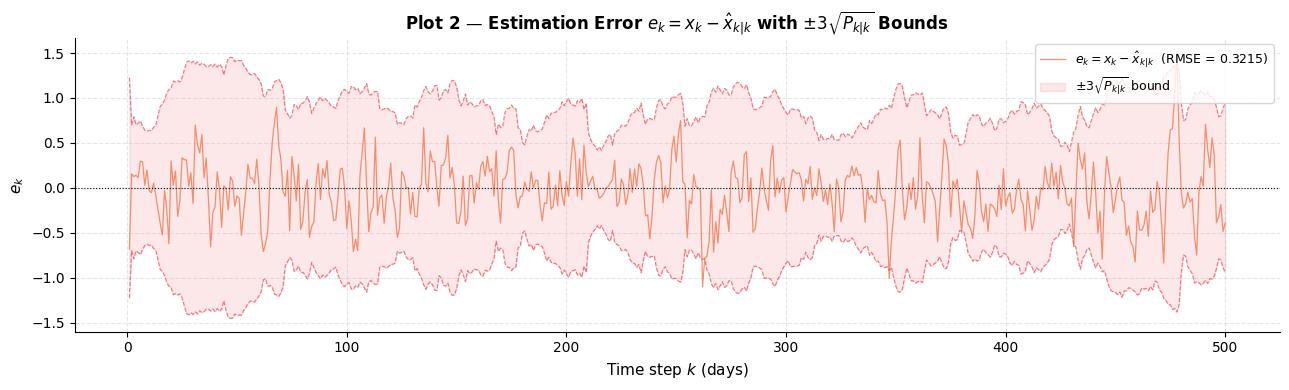

[20:08:47] INFO     | Finance_EKF | Saved → output/plot3_innovations.png


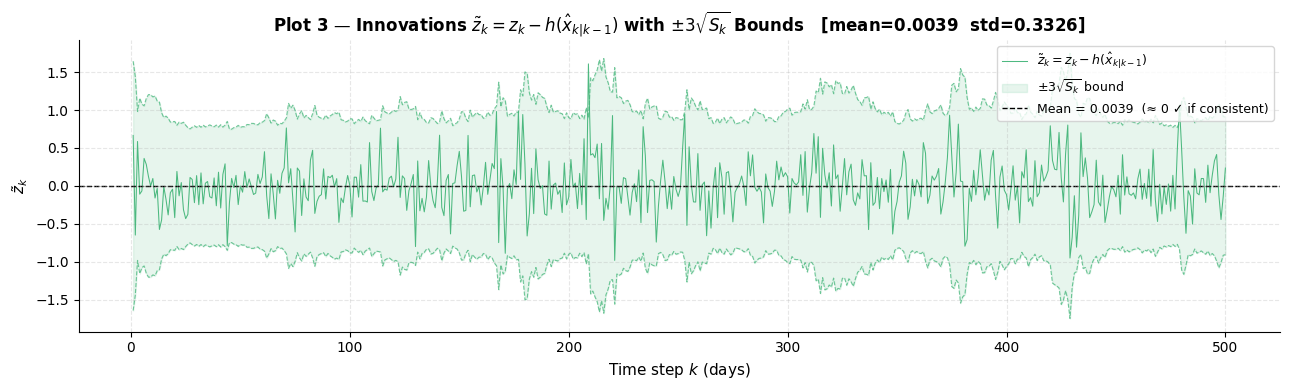

[20:08:48] INFO     | Finance_EKF | Saved → output/plot4_kalman_gain.png


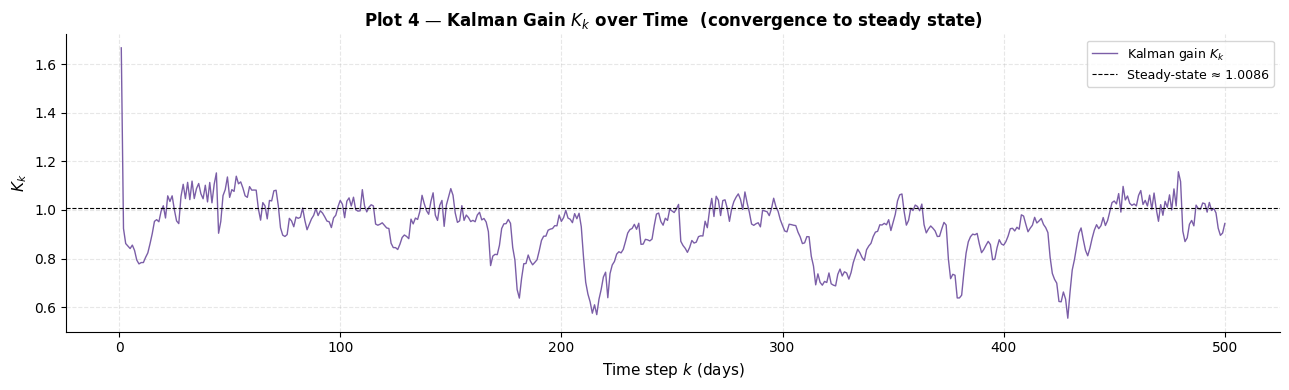

In [22]:
# Generate all 4 diagnostic plots — each saved as its own file
figs = ekf.plot_results(
    x_true   = x_true,
    save_dir = 'output',
    show     = True,
)
# Individual methods are also available:
#   ekf.plot_state_estimate(x_true, save_dir='output')
#   ekf.plot_estimation_error(x_true, save_dir='output')
#   ekf.plot_innovations(save_dir='output')
#   ekf.plot_kalman_gain(save_dir='output')
